In [5]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_FEATURES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### County Selection for Semivariogram Analysis

| Tier | FIPS | County, State | Growth Parcels | Rationale |
|------|------|--------------|----------------|-----------|
| Urban | 42101 | Philadelphia, PA | 2,077 | Uniformly urban; 142 sq mi; no suburban fringe |
| Urban | 11001 | District of Columbia | 889 | Most homogeneous density; 68 sq mi; all infill |
| Urban | 17031 | Cook, IL | 3,798 | Chicago core; dense throughout inner areas |
| Urban | 48113 | Dallas, TX | 9,002 | Dallas city proper; active infill/redevelopment |
| Urban | 06037 | Los Angeles, CA | 8,251 | Uniformly dense; infill/ADU/multifamily growth |
| Suburban | 48201 | Harris (Houston), TX | 29,557 | Sprawling metro; massive suburban ring expansion |
| Suburban | 32003 | Clark (Las Vegas), NV | 17,627 | Classic desert-edge subdivision sprawl |
| Suburban | 37183 | Wake (Raleigh), NC | 10,648 | Research Triangle tech-driven suburban growth |
| Suburban | 01089 | Madison (Huntsville), AL | 12,408 | Defense/aerospace suburban expansion |
| Suburban | 06067 | Sacramento, CA | 9,790 | State capital; Elk Grove/Folsom suburban ring |
| Exurban | 04021 | Pinal, AZ | 20,114 | Between Phoenix & Tucson; leapfrog exurban |
| Exurban | 48491 | Williamson, TX | 17,907 | North of Austin; farmland → master-planned |
| Exurban | 08123 | Weld, CO | 11,828 | North of Denver; ag → residential at metro edge |
| Exurban | 48339 | Montgomery, TX | 20,166 | North of Houston; piney woods exurban boom |
| Exurban | 45051 | Horry, SC | 15,810 | Myrtle Beach; coastal scattered development |
| Rural | 30031 | Gallatin, MT | 1,928 | Bozeman; mountain valley, ranches converting |
| Rural | 30111 | Yellowstone, MT | 2,409 | Billings; 2,649 sq mi ranch/ag county |
| Rural | 38073 | Ward, ND | 4,552 | Minot; oil boom growth in vast prairie |
| Rural | 56021 | Laramie, WY | 1,764 | Cheyenne; high plains, very large parcels |
| Rural | 46083 | Lincoln, SD | 2,981 | Sioux Falls fringe; prairie farmland transitioning |

In [6]:
# Import parcel-level table with quarter_mile_calcs
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_FEATURES}.loc_growth_cnts_parcel"
client = bigquery.Client(project=GCS_PROJECT_ID)
query = f"""
SELECT * EXCEPT(parcel_polygon, parcel_centroid, rn),
       ST_X(parcel_centroid) AS lon, 
       ST_Y(parcel_centroid) AS lat
FROM (
    SELECT *, 
           ROW_NUMBER() OVER (PARTITION BY fips ORDER BY FARM_FINGERPRINT(CAST(parcel_shape_id AS STRING))) AS rn
    FROM `{table_id}`
    WHERE fips IN ('42101','11001','17031','48113','06037',
                   '48201','32003','37183','01089','06067',
                   '04021','48491','08123','48339','45051',
                   '30031','30111','38073','56021','46083')
)
WHERE rn <= 5000
"""
growth_parcel = client.query(query).to_arrow().to_pandas()
growth_parcel.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   parcel_shape_id                        100000 non-null  int64  
 1   fips                                   100000 non-null  str    
 2   landuse_change_indicator               169 non-null     str    
 3   new_clip_indicator                     2106 non-null    str    
 4   builder_developer_ownership_indicator  822 non-null     str    
 5   recent_new_con_bldg_permit_indicator   746 non-null     str    
 6   recent_parcel_split                    5172 non-null    str    
 7   is_growth_parcel                       100000 non-null  bool   
 8   is_pre_early_dev_parcel                100000 non-null  bool   
 9   bldr_dev_qtr_mi_cnt                    100000 non-null  int64  
 10  landuse_change_qtr_mi_cnt              100000 non-null  int64  
 11 

In [7]:
# Reference documentation: https://rpubs.com/bpbond/1206397

# GOAL: Determine the optimal distance radius for growth proximity features.
# What "optimal distance" means in our context:
# The distance should be large enough to include parcels that are part of the same growth event, but small enough to exclude parcels that aren't.
# We can think of it this way:
# A developer buys 50 acres north of Austin and starts building homes. That project has a spatial footprint — all parcels within that footprint share the same growth reality.
# A parcel on the edge of that footprint (unflagged itself, but surrounded by flagged parcels) should carry the signal — it's desirable for fiber because demand is coming.
# A parcel 3 miles away in a different part of the county has nothing to do with that development. Including it would be noise.
# The optimal distance = the typical radius of a growth event's spatial footprint.

# APPROACH: Semivariogram analysis
# - For each parcel, we have a count of growth-flagged parcels within 0.25 miles.
# - We want to know: at what distance does the spatial correlation of these counts
#   die out? That distance = the natural radius for the proximity feature.
# - We do this separately for urban/suburban/exurban/rural to check if the
#   optimal radius varies by density context.

# In this context, spatial correlation is measured by asking a simple question repeatedly:
# "If I pick two parcels that are h miles apart, how different are their growth counts?"
# The semivariogram is just the average squared difference between parcel pairs, grouped by how far apart they are.

# Concretely, with our data:
# Pick parcel A (pre_early_dev_qtr_mi_cnt = 12) and parcel B (pre_early_dev_qtr_mi_cnt = 10), 0.1 miles apart → squared difference = 
# (12 − 10)^2 = 4
# Pick parcel C (= 12) and parcel D (= 3), 0.8 miles apart → squared difference = (12−3)^2 = 81
# Do this for all pairs in the sample, bin them by distance, average the squared differences per bin.
# If nearby parcels have similar counts (both have ~12 because they're in the same development cluster) → small squared differences at short distances → low semivariance → high spatial correlation.
# If distant parcels have unrelated counts (one has 12, another has 0 because they're in different parts of the county) → large squared differences at long distances → high semivariance → no spatial correlation.

# The variogram plot is literally: "average dissimilarity vs. distance." 
# When it flattens, parcels are no more different from each other than random. 
# They've stopped sharing a common growth context. That flat point = radius.


# METHODOLOGY:
# 1. Sample parcels stratified by density tier
# 2. Compute log-transformed growth counts (handles right skew)
# 3. Compute empirical semivariogram: for each distance bin, measure how different parcel counts are on average
# 4. Fit theoretical variogram models (spherical, exponential, gaussian)
# 5. Extract the "range" parameter = distance where spatial correlation ends

In [8]:
from scipy.optimize import curve_fit
from sklearn.metrics.pairwise import haversine_distances

# ── 1. Classify counties by density tier ──
# We group counties into tiers to test if the spatial range of growth differs
# by urbanicity. If it does → adaptive radius is justified.
# If it doesn't → a single universal radius works.
density_tiers = {
    'urban': ['42101', '11001', '17031', '48113', '06037'],      # Philadelphia, DC, Cook (Chicago), Dallas, Los Angeles
    'suburban': ['48201', '32003', '37183', '01089', '06067'],   # Harris (Houston), Clark (Vegas), Wake (Raleigh), Madison (Huntsville), Sacramento
    'exurban': ['04021', '48491', '08123', '48339', '45051'],    # Pinal AZ, Williamson TX, Weld CO, Montgomery TX, Horry SC
    'rural': ['30031', '30111', '38073', '56021', '46083']       # Gallatin MT, Yellowstone MT, Ward ND, Laramie WY, Lincoln SD
}

tier_map = {fips: tier for tier, fips_list in density_tiers.items() for fips in fips_list}
growth_parcel['density_tier'] = growth_parcel['fips'].map(tier_map)

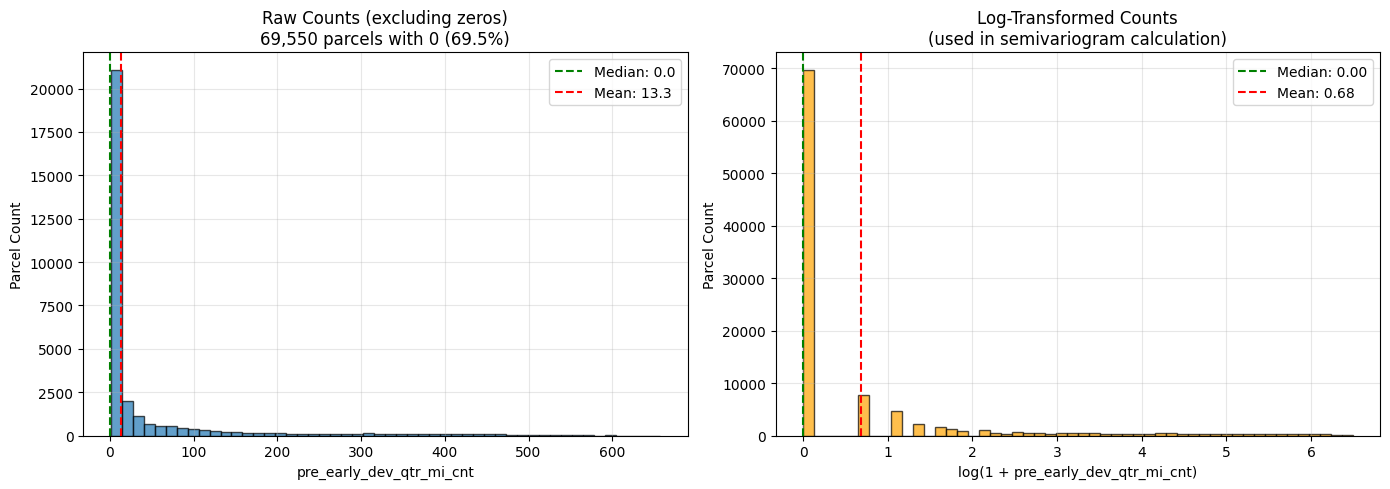

Raw: min=0, max=657, skew=5.98
Log: min=0.00, max=6.49, skew=2.34


In [9]:
# ── Distribution of log-transformed feature ──
flag_col = 'pre_early_dev_qtr_mi_cnt'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
ax = axes[0]
data_raw = growth_parcel[flag_col]
ax.hist(data_raw[data_raw > 0], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(data_raw.median(), color='green', linestyle='--', label=f'Median: {data_raw.median():.1f}')
ax.axvline(data_raw.mean(), color='red', linestyle='--', label=f'Mean: {data_raw.mean():.1f}')
ax.set_xlabel(flag_col)
ax.set_ylabel("Parcel Count")
ax.set_title(f"Raw Counts (excluding zeros)\n{(data_raw == 0).sum():,} parcels with 0 ({(data_raw == 0).mean():.1%})")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: log(1 + count)
ax = axes[1]
data_log = np.log1p(growth_parcel[flag_col])
ax.hist(data_log, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax.axvline(data_log.median(), color='green', linestyle='--', label=f'Median: {data_log.median():.2f}')
ax.axvline(data_log.mean(), color='red', linestyle='--', label=f'Mean: {data_log.mean():.2f}')
ax.set_xlabel(f"log(1 + {flag_col})")
ax.set_ylabel("Parcel Count")
ax.set_title("Log-Transformed Counts\n(used in semivariogram calculation)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats
print(f"Raw: min={data_raw.min()}, max={data_raw.max()}, skew={data_raw.skew():.2f}")
print(f"Log: min={data_log.min():.2f}, max={data_log.max():.2f}, skew={data_log.skew():.2f}")

In [ ]:
# ── 2. Empirical variogram function that is used to fit a semivariogram model
def empirical_variogram(coords, values, n_lags=30, max_dist_miles=2.0):
    """
    Compute the empirical semivariogram.
    
    For each distance bin h, computes:
        γ(h) = (1 / 2N) * Σ (Z(si) - Z(sj))²
    
    where the sum is over all parcel pairs (i,j) whose centroids are ~h miles apart.
    
    Parameters:
    -----------
    coords : (n, 2) array of [lat, lon] in degrees
        Parcel centroid coordinates. We use centroids because the growth feature
        itself is computed centroid-to-centroid (ST_DWithin from centroid).
    
    values : (n,) array of float
        The variable to analyze (log-transformed growth counts).
    
    n_lags : int, default=30
        Number of distance bins between 0 and max_dist_miles.
        More bins = finer resolution but noisier (fewer pairs per bin).
        30 bins over 2 miles = ~0.067 mile bin width.
    
    max_dist_miles : float, default=2.0
        Maximum distance to consider. Rule of thumb: set to ~half the spatial
        extent of the data. Beyond this, too few pairs exist for stable estimates.
        We expect the range to be well under 2 miles based on our initial plot.
    
    Returns:
    --------
    lag_centers : distances (midpoint of each bin, in miles)
    semivariance : γ(h) for each bin
    pair_counts : number of parcel pairs in each bin (for confidence assessment)
    """
    # Haversine distance expects radians; returns distance in radians of Earth
    coords_rad = np.radians(coords)
    dist_matrix = haversine_distances(coords_rad) * 3958.8  # Convert to miles
    
    # Extract upper triangle — each pair counted once
    i_upper, j_upper = np.triu_indices(len(values), k=1)
    distances = dist_matrix[i_upper, j_upper]
    sq_diffs = (values[i_upper] - values[j_upper]) ** 2
    
    # Bin pairs by distance and compute mean semivariance per bin
    lag_edges = np.linspace(0, max_dist_miles, n_lags + 1)
    lag_centers = (lag_edges[:-1] + lag_edges[1:]) / 2
    
    semivariance = np.zeros(n_lags)
    pair_counts = np.zeros(n_lags)
    
    for k in range(n_lags):
        mask = (distances >= lag_edges[k]) & (distances < lag_edges[k + 1])
        n_pairs = mask.sum()
        if n_pairs > 30:  # Minimum pairs for a statistically stable estimate
            semivariance[k] = 0.5 * sq_diffs[mask].mean()  # The "semi" in semivariogram
            pair_counts[k] = n_pairs
        else:
            semivariance[k] = np.nan  # Too few pairs; skip this bin
            pair_counts[k] = n_pairs
    
    return lag_centers, semivariance, pair_counts

##### Computing "only the upper triangle" in our function:

When computing pairwise distances between N parcels, we get an N×N matrix. But:

- The diagonal (parcel A vs. itself) is always 0 — useless
- The matrix is symmetric: distance(A→B) = distance(B→A)

So computing the full matrix would double-count every pair. The **upper triangle** means we only look at pairs where `i < j`

This gives $\frac{N(N-1)}{2}$ unique pairs instead of $N^2$. For 5,000 parcels: 12,497,500 unique pairs instead of 25,000,000 — each pair counted exactly once.

In the code, this is the line:
```python
i_upper, j_upper = np.triu_indices(len(values), k=1)

In [29]:
# ── 3. Define theoretical variogram models ──
# These are the candidate functions we fit to the empirical points.
# Each has 3 parameters: nugget (C0), sill (C0+C), and range (a).
#
# - nugget: micro-scale noise (semivariance at distance → 0 but not 0)
# - sill: the plateau value (= variance of the field when fully decorrelated)
# - range (a): THE ANSWER — distance at which spatial correlation ends

def spherical_model(h, nugget, sill, range_a):
    """
    Spherical: rises linearly-ish, then hits sill exactly at distance a.
    Good for: phenomena with sharp spatial boundaries (e.g., subdivision edges).
    """
    h = np.asarray(h, dtype=float)
    gamma = np.where(
        h <= range_a,
        nugget + (sill - nugget) * (1.5 * (h / range_a) - 0.5 * (h / range_a)**3),
        sill
    )
    return gamma

def exponential_model(h, nugget, sill, range_a):
    """
    Exponential: approaches sill asymptotically, never truly reaches it.
    "Effective range" (95% of sill) = 3 * range_a.
    Good for: gradual decay of correlation.
    """
    h = np.asarray(h, dtype=float)
    gamma = nugget + (sill - nugget) * (1 - np.exp(-h / range_a))
    return gamma

def gaussian_model(h, nugget, sill, range_a):
    """
    Gaussian: very flat near origin (nearby parcels are very similar), then rises.
    "Effective range" (95% of sill) = sqrt(3) * range_a.
    Good for: smooth continuous phenomena.
    """
    h = np.asarray(h, dtype=float)
    gamma = nugget + (sill - nugget) * (1 - np.exp(-(h / range_a)**2))
    return gamma

In [52]:
# ── 4. Compute empirical variogram + fit models per tier ──
# Using log-transformed counts (not binary) because:
# - We care about intensity of growth, not just presence/absence
# - log(1+x) handles zeros and compresses right skew so outliers don't dominate

flag_col = 'pre_early_dev_qtr_mi_cnt'
# options are: ['bldr_dev_qtr_mi_cnt', 'landuse_change_qtr_mi_cnt',	'new_permit_qtr_mi_cnt', 'pre_early_dev_qtr_mi_cnt']
sample_size = 5000  # Per tier. Gives ~12.5M pairs — tractable in ~30s per tier.

results = {}
fit_results = {}

models = {
    'spherical': spherical_model,
    'exponential': exponential_model,
    'gaussian': gaussian_model
}

for tier in density_tiers:
    subset = growth_parcel[growth_parcel['density_tier'] == tier]
    sample = subset.sample(n=min(sample_size, len(subset)), random_state=42)
    
    coords = sample[['lat', 'lon']].values
    values = np.log1p(sample[flag_col].values)  # log(1 + count) to handle skew
    
    lag_centers, semivariance, pair_counts = empirical_variogram(
        coords, values, n_lags=30, max_dist_miles=2.0
    )
    results[tier] = (lag_centers, semivariance, pair_counts)
    
    # ── Fit all 3 models, pick best ──
    mask = ~np.isnan(semivariance)
    h_valid = lag_centers[mask]
    sv_valid = semivariance[mask]
    
    # Initial guesses: nugget=0, sill=max observed semivariance, range=0.5 mi
    p0 = [0.0, sv_valid[-1], 0.5]
    bounds = ([0, 0, 0.01], [sv_valid.max(), sv_valid.max() * 2, 5.0])
    
    best_model = None
    best_rss = np.inf
    best_params = None
    
    for model_name, model_func in models.items():
        try:
            popt, _ = curve_fit(model_func, h_valid, sv_valid, p0=p0, bounds=bounds, maxfev=5000)
            residuals = sv_valid - model_func(h_valid, *popt)
            rss = np.sum(residuals**2)
            
            if rss < best_rss:
                best_rss = rss
                best_model = model_name
                best_params = popt
        except RuntimeError:
            continue  # Model failed to converge; skip it
    
    # For exponential: effective range = 3a (95% of sill)
    # For gaussian: effective range = sqrt(3) * a (95% of sill)
    # For spherical: range = a (exact)
    fitted_nugget, fitted_sill, fitted_range_a = best_params
    if best_model == 'exponential':
        effective_range = 3 * fitted_range_a
    elif best_model == 'gaussian':
        effective_range = np.sqrt(3) * fitted_range_a
    else:  # spherical
        effective_range = fitted_range_a
    
    fit_results[tier] = {
        'model': best_model,
        'nugget': fitted_nugget,
        'sill': fitted_sill,
        'range_param_a': fitted_range_a,
        'effective_range_miles': effective_range,
        'rss': best_rss
    }
    
    print(f"{tier}: best model = {best_model}, effective range = {effective_range:.3f} miles, "
          f"nugget = {fitted_nugget:.4f}, sill = {fitted_sill:.4f}")

urban: best model = gaussian, effective range = 0.589 miles, nugget = 0.0840, sill = 0.6312
suburban: best model = gaussian, effective range = 0.691 miles, nugget = 0.0399, sill = 1.0195
exurban: best model = gaussian, effective range = 0.675 miles, nugget = 0.0115, sill = 1.6826
rural: best model = gaussian, effective range = 0.979 miles, nugget = 0.0494, sill = 1.4020


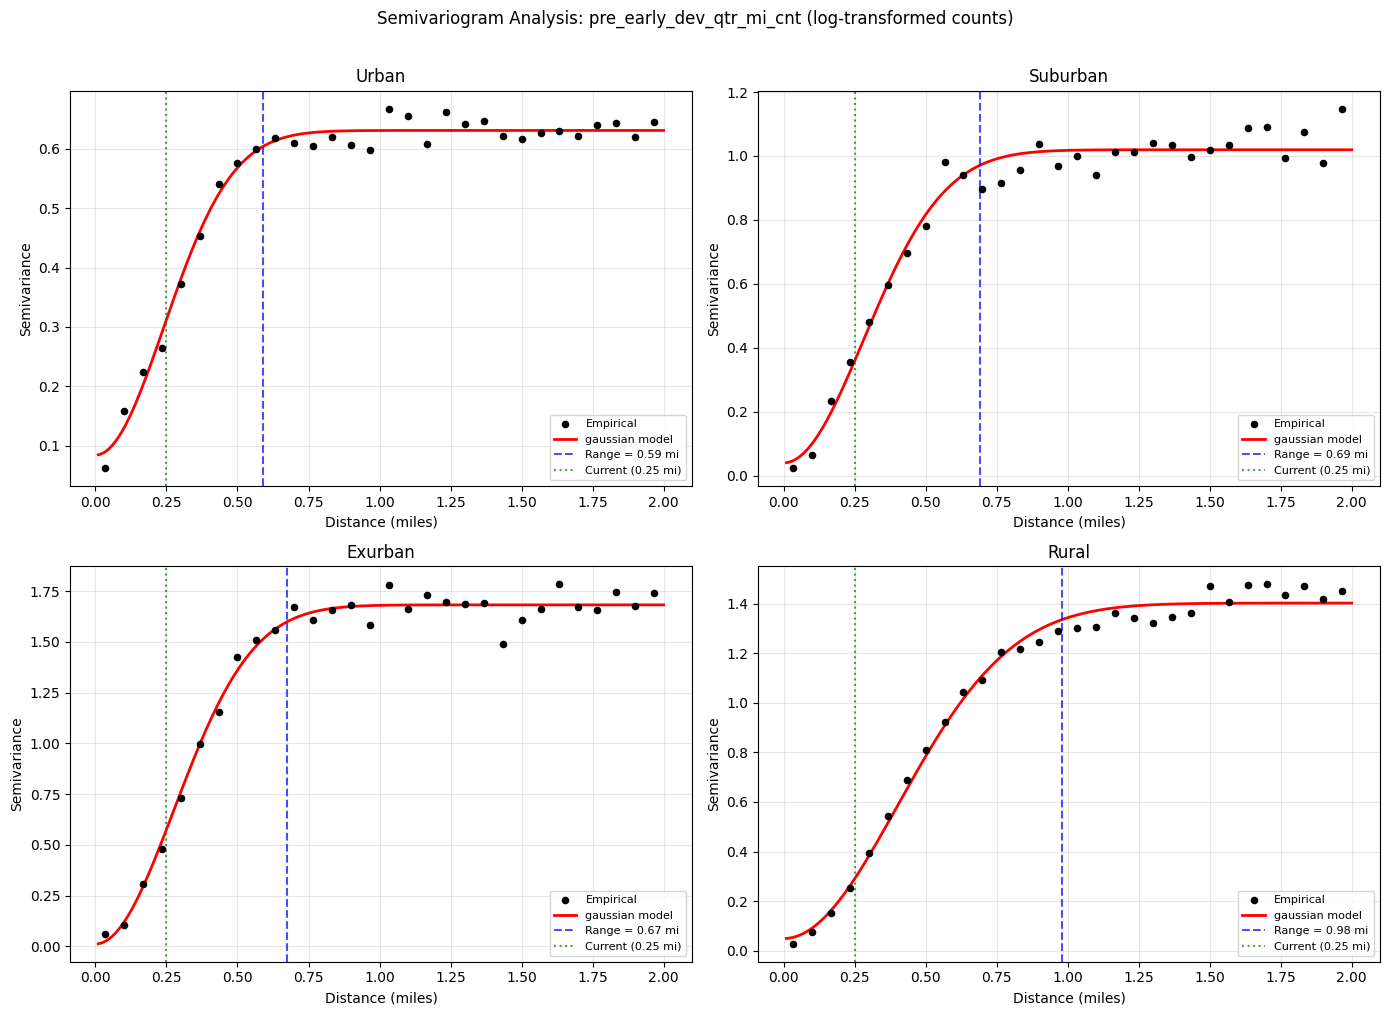

In [53]:
# ── 5. Plot: empirical points + fitted model curves ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, tier in enumerate(density_tiers):
    ax = axes[idx]
    lags, sv, counts = results[tier]
    mask = ~np.isnan(sv)
    
    # Empirical points
    ax.scatter(lags[mask], sv[mask], color='black', s=20, zorder=5, label='Empirical')
    
    # Fitted model curve
    fit = fit_results[tier]
    model_func = models[fit['model']]
    h_smooth = np.linspace(0.01, 2.0, 200)
    fitted_curve = model_func(h_smooth, fit['nugget'], fit['sill'], fit['range_param_a'])
    ax.plot(h_smooth, fitted_curve, 'r-', linewidth=2, label=f"{fit['model']} model")
    
    # Mark the effective range
    ax.axvline(fit['effective_range_miles'], color='blue', linestyle='--', alpha=0.7,
               label=f"Range = {fit['effective_range_miles']:.2f} mi")
    
    # Mark the current 0.25 mi radius for comparison
    ax.axvline(0.25, color='green', linestyle=':', alpha=0.7, label='Current (0.25 mi)')
    
    ax.set_xlabel("Distance (miles)")
    ax.set_ylabel("Semivariance")
    ax.set_title(f"{tier.title()}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Semivariogram Analysis: {flag_col} (log-transformed counts)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [54]:
# ── 6. Summary table ──
summary = pd.DataFrame(fit_results).T
summary = summary[['model', 'effective_range_miles', 'nugget', 'sill', 'rss']]
summary['effective_range_miles'] = summary['effective_range_miles'].round(3)
summary['nugget'] = summary['nugget'].round(4)
summary['sill'] = summary['sill'].round(4)
print("═" * 70)
print(f"Feature analyzed: {flag_col} (log1p transformed)")
print(f"Current radius: 0.25 miles")
print("═" * 70)
print(summary.to_string())
print("═" * 70)
print("\nInterpretation:")
print("• effective_range_miles = distance where spatial correlation ends")
print("• If range >> 0.25: current radius is missing signal")
print("• If range ≈ 0.25: current radius is appropriate")
print("• If ranges are similar across tiers: universal radius works")
print("• If ranges diverge: adaptive radius is justified")

══════════════════════════════════════════════════════════════════════
Feature analyzed: pre_early_dev_qtr_mi_cnt (log1p transformed)
Current radius: 0.25 miles
══════════════════════════════════════════════════════════════════════
             model effective_range_miles  nugget    sill       rss
urban     gaussian                 0.589   0.084  0.6312  0.010454
suburban  gaussian                 0.691  0.0399  1.0195  0.071672
exurban   gaussian                 0.675  0.0115  1.6826  0.099782
rural     gaussian                 0.979  0.0494   1.402  0.055623
══════════════════════════════════════════════════════════════════════

Interpretation:
• effective_range_miles = distance where spatial correlation ends
• If range >> 0.25: current radius is missing signal
• If range ≈ 0.25: current radius is appropriate
• If ranges are similar across tiers: universal radius works
• If ranges diverge: adaptive radius is justified


In [42]:
# Compute R² for each tier
for tier in fit_results:
    lags, sv, _ = results[tier]
    mask = ~np.isnan(sv)
    sv_valid = sv[mask]
    tss = np.sum((sv_valid - sv_valid.mean())**2)
    r_squared = 1 - fit_results[tier]['rss'] / tss
    fit_results[tier]['r_squared'] = r_squared
    print(f"{tier}: R² = {r_squared:.4f}")

urban: R² = 0.9876
suburban: R² = 0.9675
exurban: R² = 0.9261
rural: R² = 0.9756
